<a href="https://colab.research.google.com/github/sabithakrishnan/timeseries-analysis/blob/main/timeseriesAnalysis_sarima.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install pmdarima


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 11.2 MB/s eta 0:00:00


--- SARIMA Performance Results ---
MAE               : 1.4818
RMSE              : 2.0108
R² Score          : -1.1094
Adjusted R² Score : -1.1117


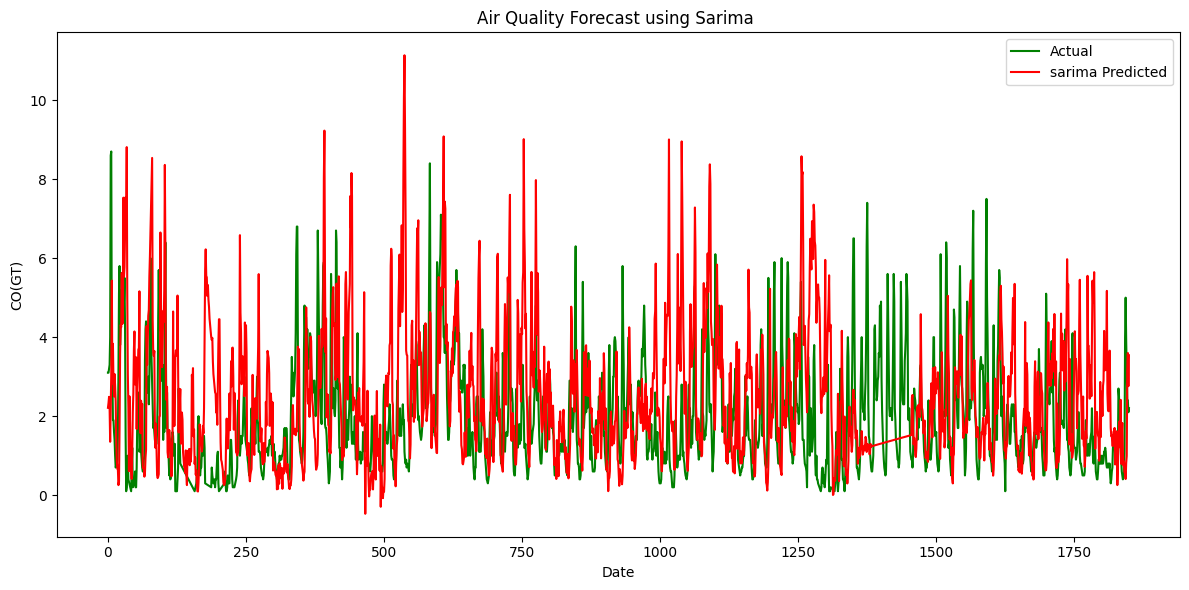

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
import warnings
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
warnings.filterwarnings('ignore')

#Loading data
df = pd.read_csv("/content/AirQualityUCI.csv", sep=';', decimal=',')
#preprocessing of data
df.dropna(how='all', inplace=True)
df.replace(-200, np.nan, inplace=True)
target = df['CO(GT)'].copy().interpolate(method='linear')
target = target.dropna().reset_index(drop=True)
#train and test split
test_len = 1850
train = target.iloc[:-test_len]
test = target.iloc[-test_len:]
#Model development
base_model = SARIMAX(train,
                     order=(1, 0, 1),
                     seasonal_order=(1, 0, 0, 24),
                     enforce_stationarity=False,
                     enforce_invertibility=False)
#Fitting
base_results = base_model.fit(disp=False)
#prediction
all_predictions = base_results.fittedvalues
# Isolate only the predictions matching our test set window
predictions_test = all_predictions.iloc[-test_len:]
# ACCURACY METRICS

y_true = test.values
y_pred = predictions_test.values # Corrected to use predictions_test

# MAE, RMSE, and R2
mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
r2 = r2_score(y_true, y_pred)

# Adjusted R2
n = len(y_true)     # Number of test data points
k = base_model.order[0] + base_model.order[2] # Number of predictors (AR + MA coefficients) - Corrected stepwise_model to base_model
adjusted_r2 = 1 - ((1 - r2) * (n - 1) / (n - k - 1))

# ==========================================
# Evaluation Metrics results
# ==========================================
print(f"--- SARIMA Performance Results ---")
print(f"MAE               : {mae:.4f}")
print(f"RMSE              : {rmse:.4f}")
print(f"R² Score          : {r2:.4f}")
print(f"Adjusted R² Score : {adjusted_r2:.4f}")
plt.figure(figsize=(12, 6))

# Reset indices to 0-1850 scale to match your exact visual format
x_axis = np.arange(test_len)

plt.plot(x_axis, test.values, label='Actual', color='green', linewidth=1.5)
plt.plot(x_axis,predictions_test, label='sarima Predicted', color='red', linewidth=1.5)

plt.title('Air Quality Forecast using Sarima ', fontsize=12)
plt.xlabel('Date', fontsize=10)
plt.ylabel('CO(GT)', fontsize=10)
plt.legend(loc='upper right')
#plt.xlim(-50, test_len + 50)
plt.tight_layout()
plt.show()